# HR Analytics — Exploratory Data Analysis

**Dataset:** IBM HR Analytics Employee Attrition & Performance (4,327 employees, 31 columns)
**Goal:** Explore attrition patterns across department, tenure, age, and employee experience, and validate
which of the visual patterns are statistically significant rather than noise.

This notebook covers: data quality checks, univariate distributions, attrition breakdowns,
correlation analysis, hypothesis testing, and a validation of the rule-based HR Risk Score
used in the Power BI dashboard.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind

sns.set_style("whitegrid")


## 1. Data Loading & Overview

In [2]:
df = pd.read_csv("HR_Analytics_Cleaned_Master.csv")
df

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeID,Gender,JobLevel,...,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,Education_Label,JobSatisfaction_Label,EnvironmentSatisfaction_Label,WorkLifeBalance_Label,PerformanceRating_Label
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,Female,1,...,3.0,4.0,2.0,3,3,College,Very High,High,Good,Excellent
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,2,Female,1,...,3.0,2.0,4.0,2,4,Below College,Medium,High,Best,Outstanding
2,32,No,Travel_Frequently,Research & Development,17,4,Other,3,Male,4,...,2.0,2.0,1.0,3,3,Master,Medium,Medium,Bad,Excellent
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,4,Male,3,...,4.0,4.0,3.0,2,3,Doctor,Very High,Very High,Better,Excellent
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,5,Male,1,...,4.0,1.0,3.0,3,3,Below College,Low,Very High,Better,Excellent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4322,29,No,Travel_Rarely,Sales,4,3,Other,4405,Female,2,...,3.0,4.0,3.0,2,3,Bachelor,Very High,High,Better,Excellent
4323,42,No,Travel_Rarely,Research & Development,5,4,Medical,4406,Female,1,...,4.0,1.0,3.0,3,3,Master,Low,Very High,Better,Excellent
4324,29,No,Travel_Rarely,Research & Development,2,4,Medical,4407,Male,1,...,4.0,4.0,3.0,2,3,Master,Very High,Very High,Better,Excellent
4325,25,No,Travel_Rarely,Research & Development,25,2,Life Sciences,4408,Male,2,...,1.0,3.0,3.0,3,4,College,High,Low,Better,Outstanding


In [3]:
df.head(10)

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeID,Gender,JobLevel,...,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,Education_Label,JobSatisfaction_Label,EnvironmentSatisfaction_Label,WorkLifeBalance_Label,PerformanceRating_Label
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,Female,1,...,3.0,4.0,2.0,3,3,College,Very High,High,Good,Excellent
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,2,Female,1,...,3.0,2.0,4.0,2,4,Below College,Medium,High,Best,Outstanding
2,32,No,Travel_Frequently,Research & Development,17,4,Other,3,Male,4,...,2.0,2.0,1.0,3,3,Master,Medium,Medium,Bad,Excellent
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,4,Male,3,...,4.0,4.0,3.0,2,3,Doctor,Very High,Very High,Better,Excellent
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,5,Male,1,...,4.0,1.0,3.0,3,3,Below College,Low,Very High,Better,Excellent
5,46,No,Travel_Rarely,Research & Development,8,3,Life Sciences,6,Female,4,...,3.0,2.0,2.0,3,3,Bachelor,Medium,High,Good,Excellent
6,28,Yes,Travel_Rarely,Research & Development,11,2,Medical,7,Male,2,...,1.0,3.0,1.0,3,4,College,High,Low,Bad,Outstanding
7,29,No,Travel_Rarely,Research & Development,18,3,Life Sciences,8,Male,2,...,1.0,2.0,3.0,3,4,Bachelor,Medium,Low,Better,Outstanding
8,31,No,Travel_Rarely,Research & Development,1,3,Life Sciences,9,Male,3,...,2.0,4.0,3.0,3,4,Bachelor,Very High,Medium,Better,Outstanding
9,25,No,Non-Travel,Research & Development,7,4,Medical,10,Female,4,...,2.0,1.0,3.0,3,3,Master,Low,Medium,Better,Excellent


In [4]:
df.shape

(4327, 31)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4327 entries, 0 to 4326
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            4327 non-null   int64  
 1   Attrition                      4327 non-null   str    
 2   BusinessTravel                 4327 non-null   str    
 3   Department                     4327 non-null   str    
 4   DistanceFromHome               4327 non-null   int64  
 5   Education                      4327 non-null   int64  
 6   EducationField                 4327 non-null   str    
 7   EmployeeID                     4327 non-null   int64  
 8   Gender                         4327 non-null   str    
 9   JobLevel                       4327 non-null   int64  
 10  JobRole                        4327 non-null   str    
 11  MaritalStatus                  4327 non-null   str    
 12  MonthlyIncome                  4327 non-null   int64  
 13 

### Data Quality Validation

Rather than assuming the dataset needs cleaning, this section checks for the usual problems —
missing values and duplicate rows — before doing any analysis.

In [6]:
df.isnull().sum()

Age                              0
Attrition                        0
BusinessTravel                   0
Department                       0
DistanceFromHome                 0
Education                        0
EducationField                   0
EmployeeID                       0
Gender                           0
JobLevel                         0
JobRole                          0
MaritalStatus                    0
MonthlyIncome                    0
NumCompaniesWorked               0
PercentSalaryHike                0
StockOptionLevel                 0
TotalWorkingYears                0
TrainingTimesLastYear            0
YearsAtCompany                   0
YearsSinceLastPromotion          0
YearsWithCurrManager             0
EnvironmentSatisfaction          0
JobSatisfaction                  0
WorkLifeBalance                  0
JobInvolvement                   0
PerformanceRating                0
Education_Label                  0
JobSatisfaction_Label            0
EnvironmentSatisfact

In [7]:
df.duplicated().sum()

np.int64(0)

**Finding:** No missing values and no duplicate rows were found. The dataset was already clean
on arrival — no imputation or row removal was necessary. (This is worth stating explicitly rather
than claiming cleaning work that wasn't actually required.)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,4327.0,36.916570,9.143345,18.0,30.0,36.0,43.0,60.0
DistanceFromHome,4327.0,9.186966,8.092618,1.0,2.0,7.0,14.0,29.0
Education,4327.0,2.913797,1.024080,1.0,2.0,3.0,4.0,5.0
EmployeeID,4327.0,2208.812803,1273.370663,1.0,1105.5,2212.0,3312.5,4409.0
JobLevel,4327.0,2.067021,1.107342,1.0,1.0,2.0,3.0,5.0
MonthlyIncome,4327.0,65029.244280,46976.222828,10090.0,29260.0,49360.0,83805.0,199990.0
NumCompaniesWorked,4327.0,2.689161,2.491730,0.0,1.0,2.0,4.0,9.0
PercentSalaryHike,4327.0,15.210307,3.658903,11.0,12.0,14.0,18.0,25.0
StockOptionLevel,4327.0,0.794777,0.853017,0.0,0.0,1.0,1.0,3.0
TotalWorkingYears,4327.0,11.272244,7.779457,0.0,6.0,10.0,15.0,40.0


**Finding:** `MonthlyIncome` and `YearsAtCompany` are both right-skewed (mean well above median),
which is expected for compensation and tenure data — a small number of senior, highly-paid employees
pull the average up. This is confirmed visually in the distribution plots below.

## 2. Correlation Analysis

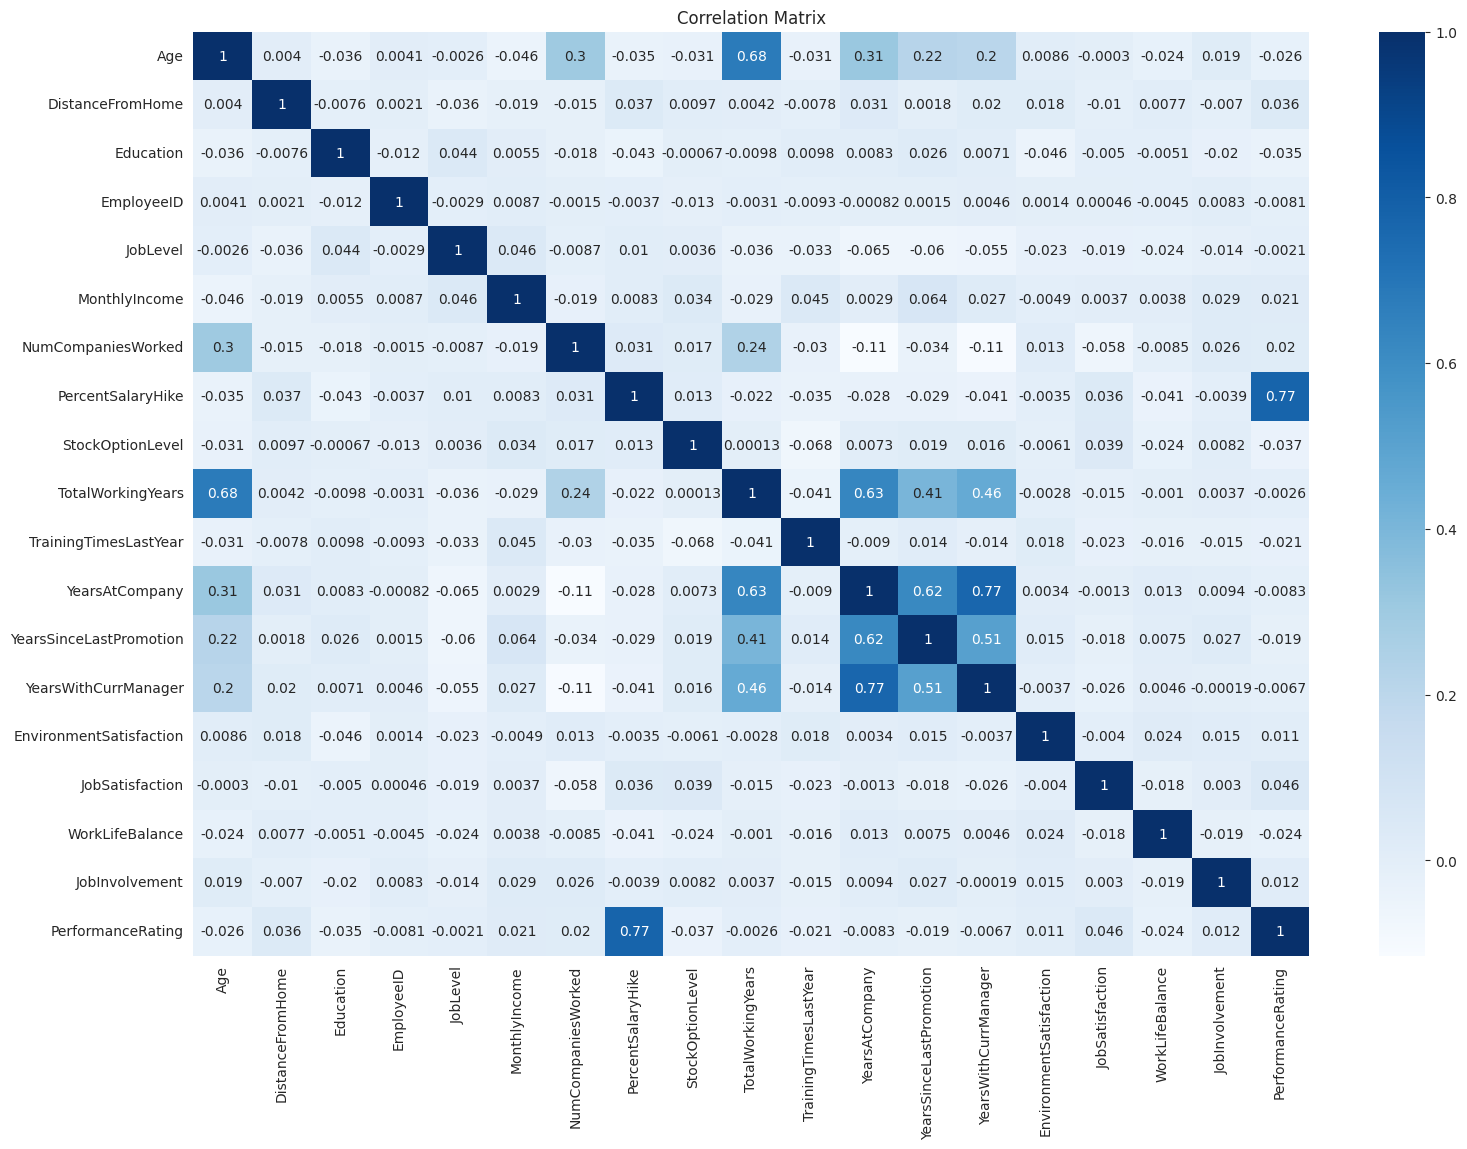

In [9]:
plt.figure(figsize=(18,12))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="Blues")

plt.title("Correlation Matrix")
plt.show()


**Finding:** The strongest relationships are all tenure-related, not attrition-related:
`YearsWithCurrManager` vs `YearsAtCompany` (r ≈ 0.77), `PerformanceRating` vs `PercentSalaryHike`
(r ≈ 0.77), and `TotalWorkingYears` vs `Age` (r ≈ 0.68) — all logical (longer tenure means more time
with the same manager; higher-rated employees get bigger raises). No pair of numeric features is
strongly collinear enough to be a concern for the analysis below.

## 3. Univariate Analysis
Distribution of individual variables before looking at attrition specifically.

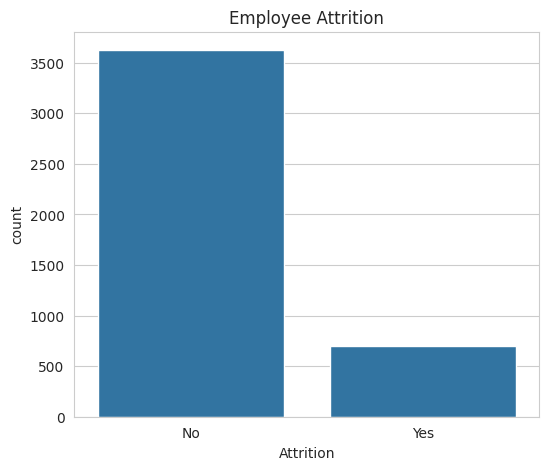

In [10]:
# Employee Attrition
plt.figure(figsize = (6,5))

sns.countplot(data = df,
             x = 'Attrition')
plt.title('Employee Attrition')
plt.show()


**Finding:** 701 of 4,327 employees (16.2%) have left — a class imbalance worth keeping in mind when reading any attrition breakdown below, since smaller subgroups can swing that percentage a lot.

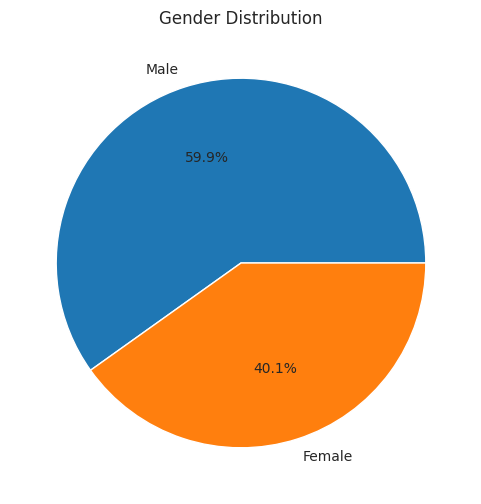

In [11]:
# Gender Distribution
plt.figure(figsize=(6,6))

df['Gender'].value_counts().plot.pie(autopct='%1.1f%%')

plt.ylabel("")
plt.title("Gender Distribution")

plt.show()


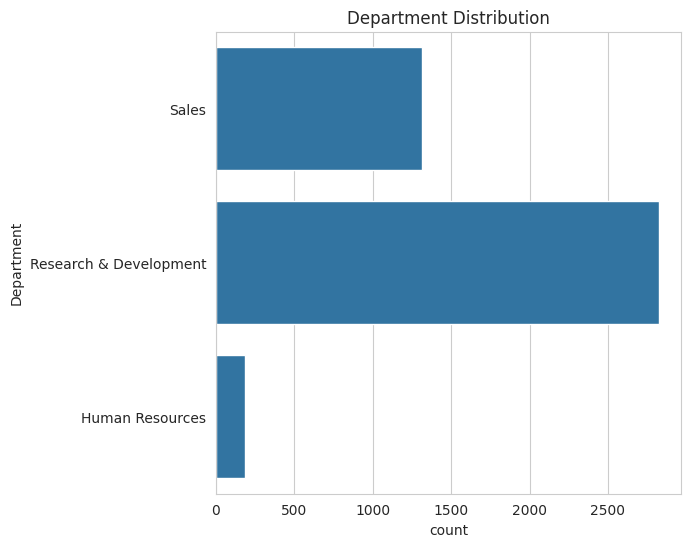

In [12]:
# Department Distribution
plt.figure(figsize=(6,6))

sns.countplot(
    data=df,
    y='Department'
)
plt.title('Department Distribution')
plt.show()


**Finding:** Research & Development is by far the largest department (2,824 employees), with Human Resources the smallest (188). Keep this in mind for the attrition-by-department comparison next — HR's small size means its attrition rate is more sensitive to a handful of people leaving.

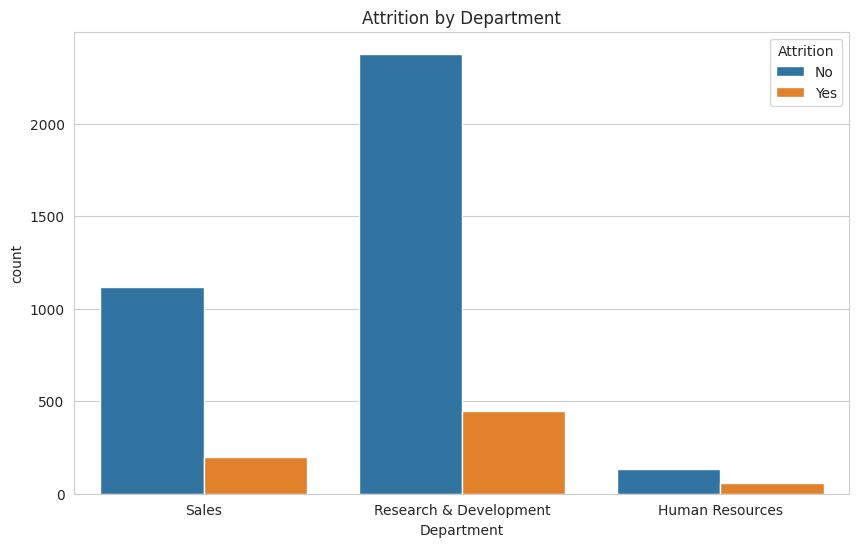

In [13]:
# Attrition by Department
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='Department',
    hue='Attrition'
)
plt.title('Attrition by Department')
plt.show()


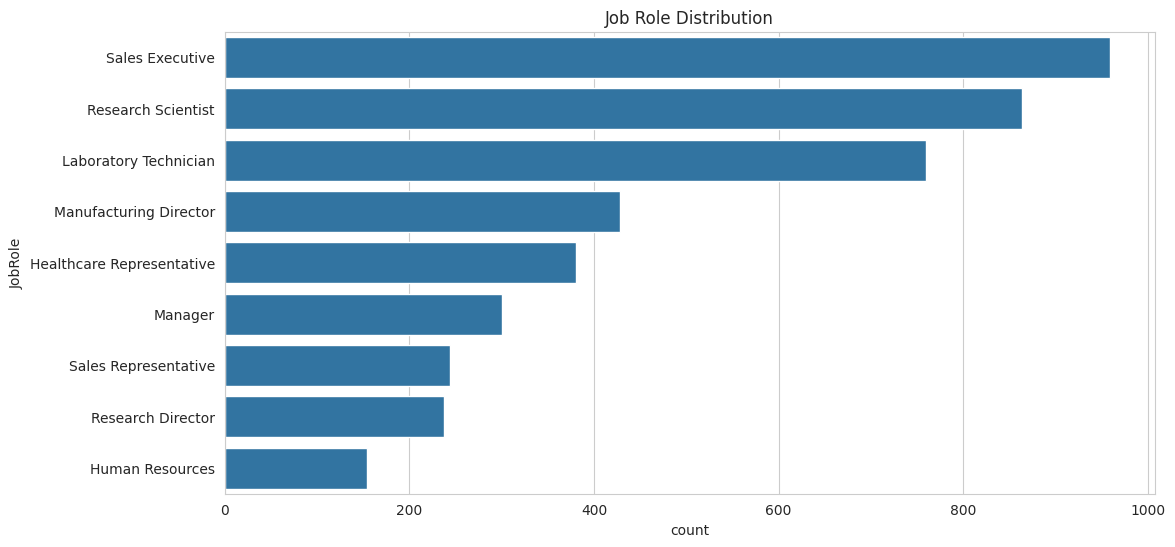

In [14]:
# Job Role Distribution
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='JobRole',
    order=df['JobRole'].value_counts().index
)
plt.title('Job Role Distribution')
plt.show()


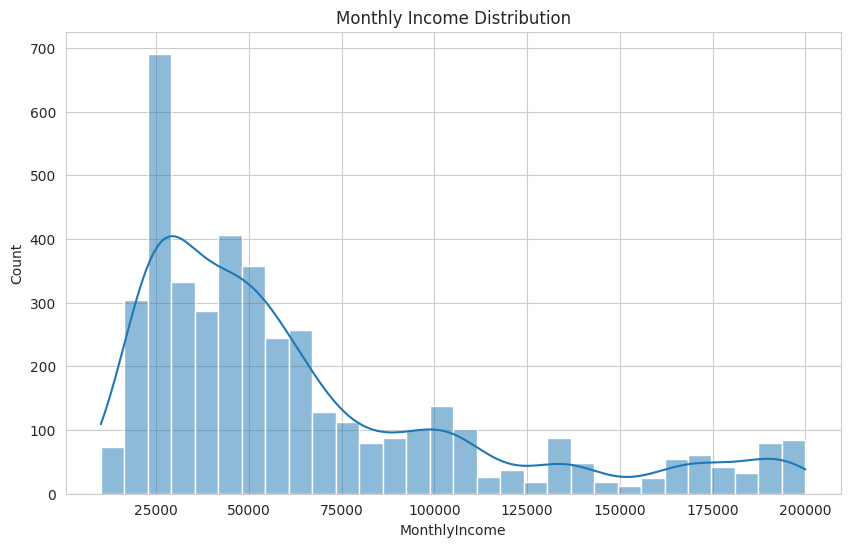

In [15]:
# Monthly Income Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    df['MonthlyIncome'],
    bins=30,
    kde=True
)
plt.title('Monthly Income Distribution')
plt.show()


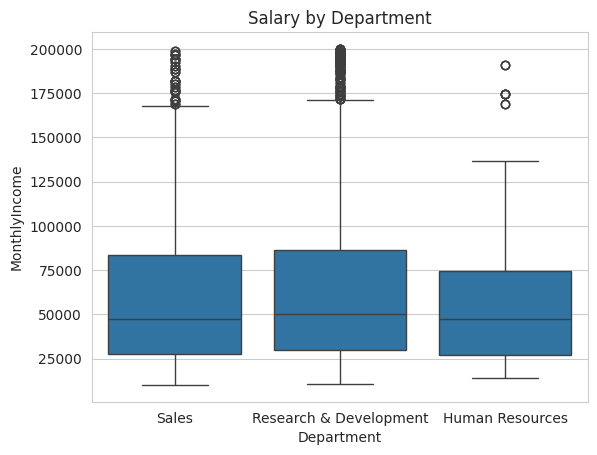

In [16]:
# Salary by Department
sns.boxplot(
    data=df,
    x='Department',
    y='MonthlyIncome'
)
plt.title('Salary by Department')
plt.show()


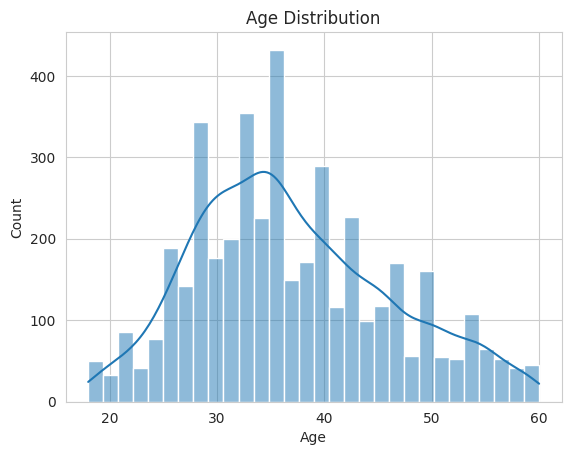

In [17]:
# Age Distribution
sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)
plt.title('Age Distribution')
plt.show()


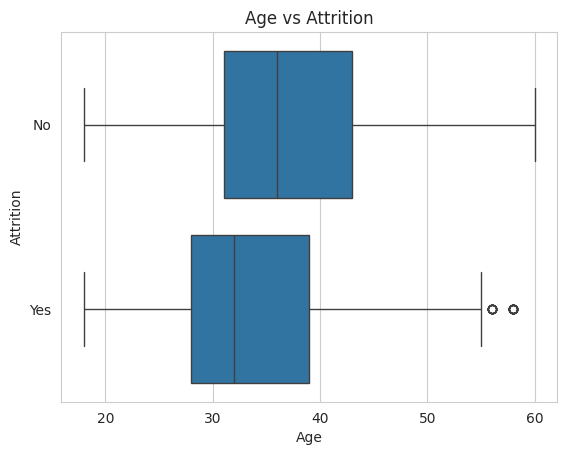

In [18]:
# Age vs Attrition
sns.boxplot(
    data=df,
    y='Attrition',
    x='Age'
)
plt.title('Age vs Attrition')
plt.show()


**Finding:** Employees who left skew younger. This is tested formally in Section 4 rather than left as a visual impression.

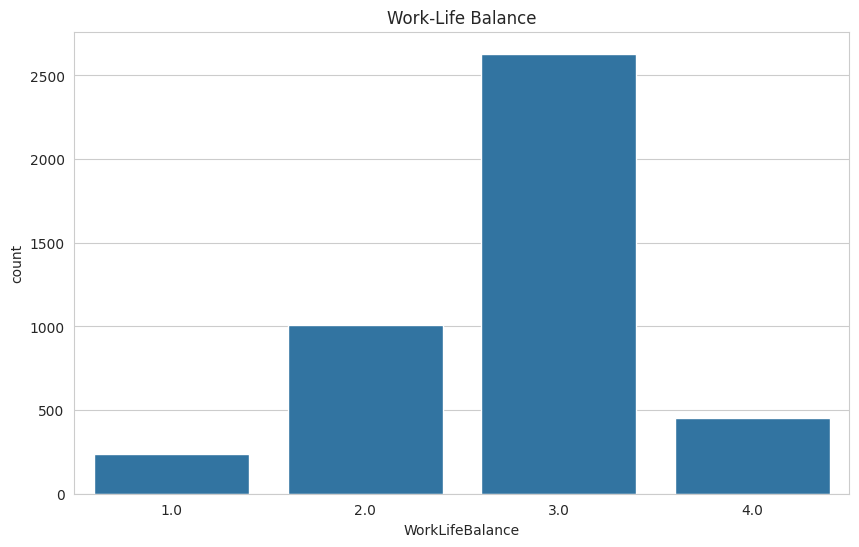

In [19]:
# Work-Life Balance
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='WorkLifeBalance'
)
plt.title('Work-Life Balance')
plt.show()


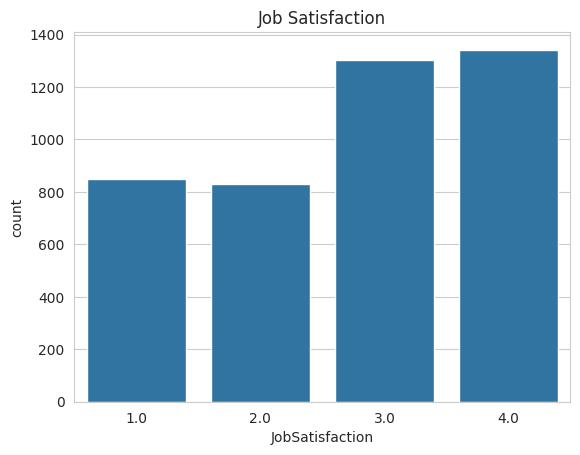

In [20]:
# Job Satisfaction
sns.countplot(
    data=df,
    x='JobSatisfaction'
)
plt.title('Job Satisfaction')
plt.show()


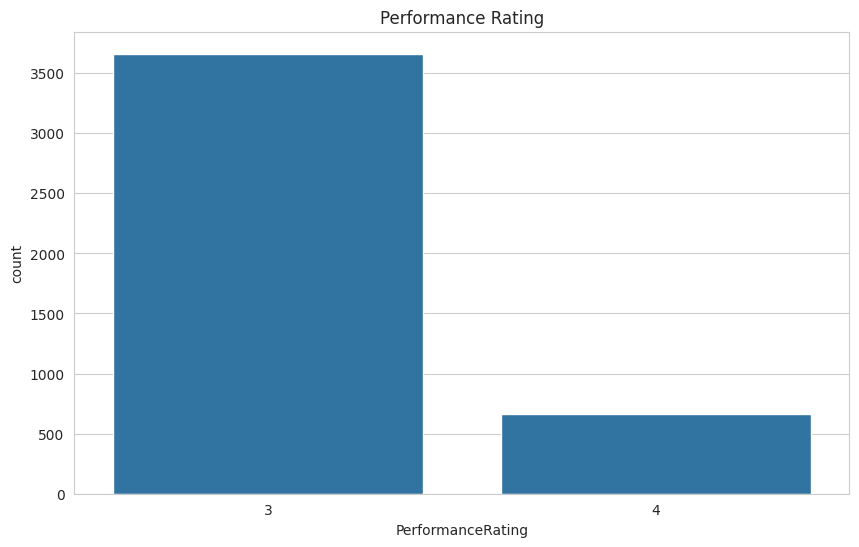

In [21]:
# Performance Rating
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='PerformanceRating'
)
plt.title("Performance Rating")
plt.show()


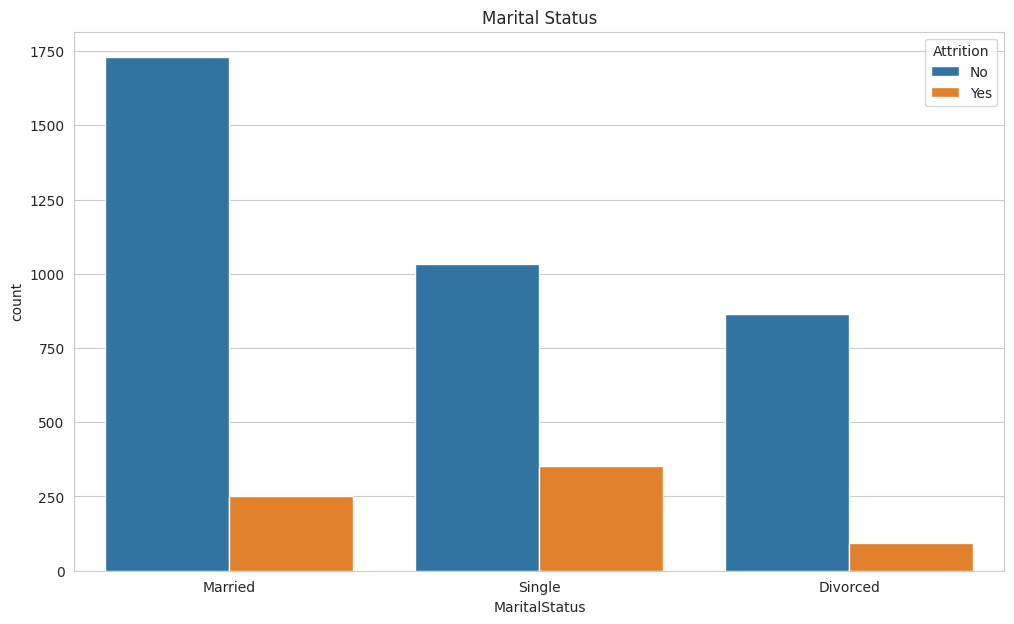

In [22]:
# Marital Status
plt.figure(figsize=(12,7))

sns.countplot(
    data=df,
    x='MaritalStatus',
    hue='Attrition'
)
plt.title('Marital Status')
plt.show()


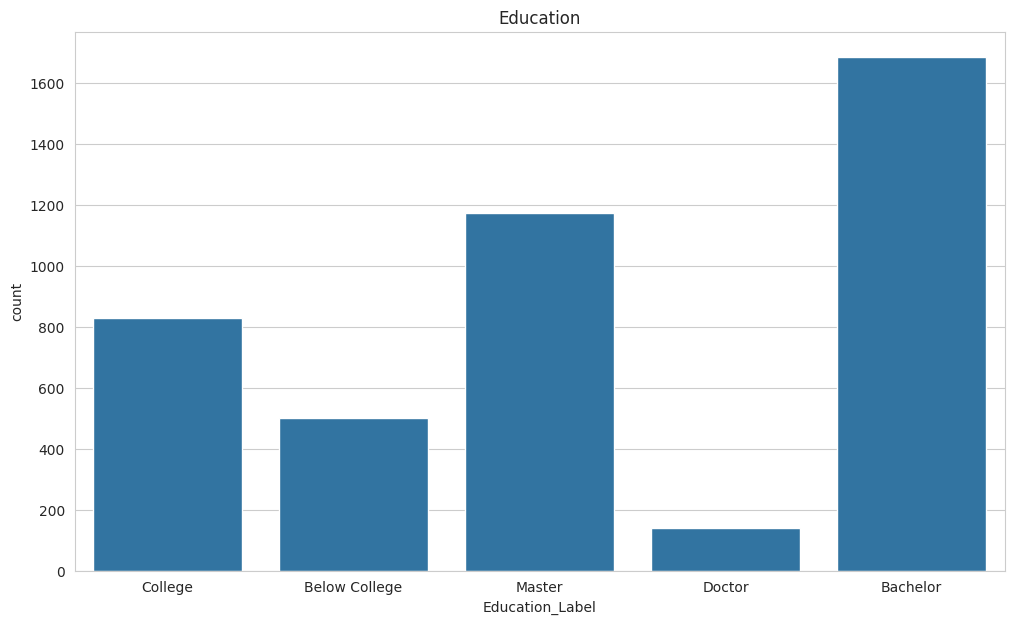

In [23]:
# Education
plt.figure(figsize=(12,7))

sns.countplot(
    data=df,
    x='Education_Label'
)
plt.title('Education')
plt.show()


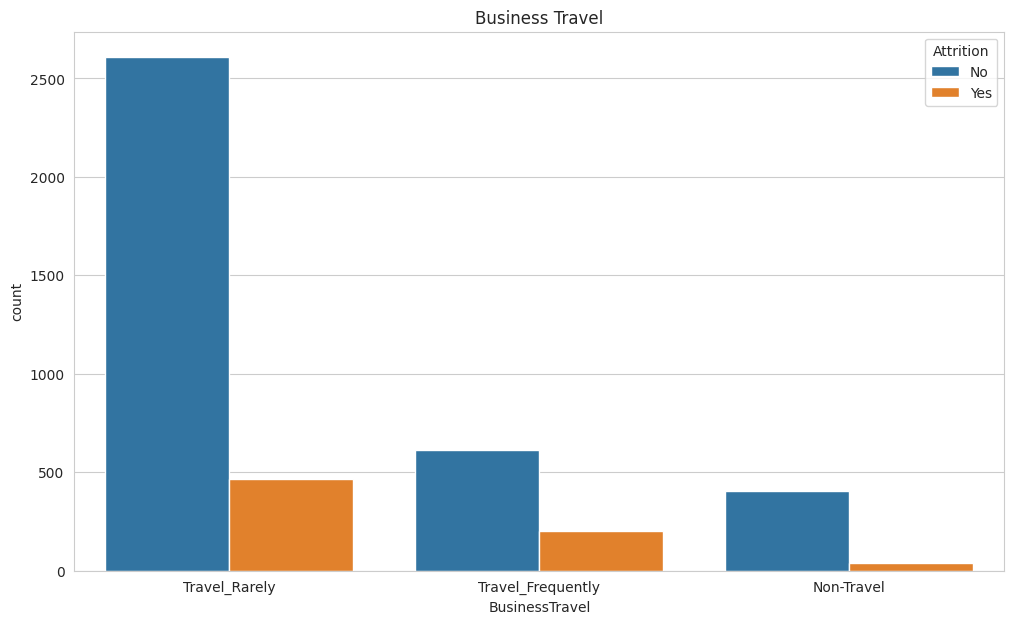

In [24]:
# Business Travel
plt.figure(figsize=(12,7))

sns.countplot(
    data=df,
    x='BusinessTravel',
    hue='Attrition'
)
plt.title('Business Travel')
plt.show()


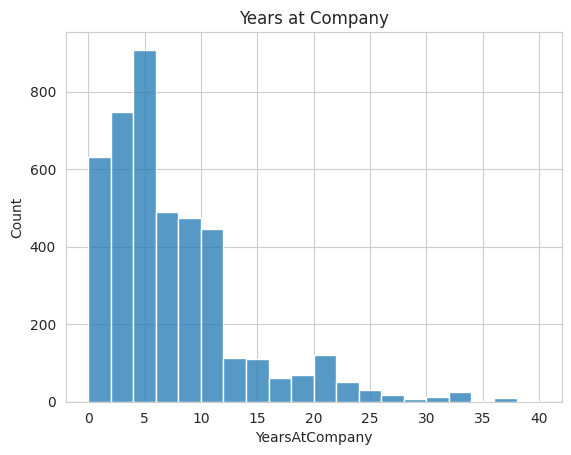

In [25]:
# Years at Company
sns.histplot(
    df['YearsAtCompany'],
    bins=20,
    # kde=True
)
plt.title('Years at Company')
plt.show()


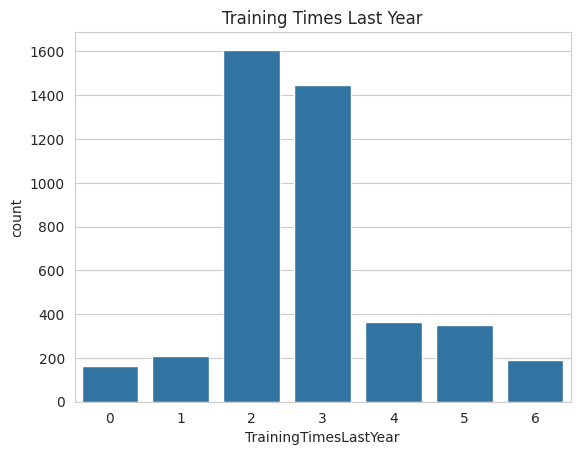

In [26]:
# Training Times Last Year
sns.countplot(
    data=df,
    x='TrainingTimesLastYear'
)
plt.title('Training Times Last Year')
plt.show()


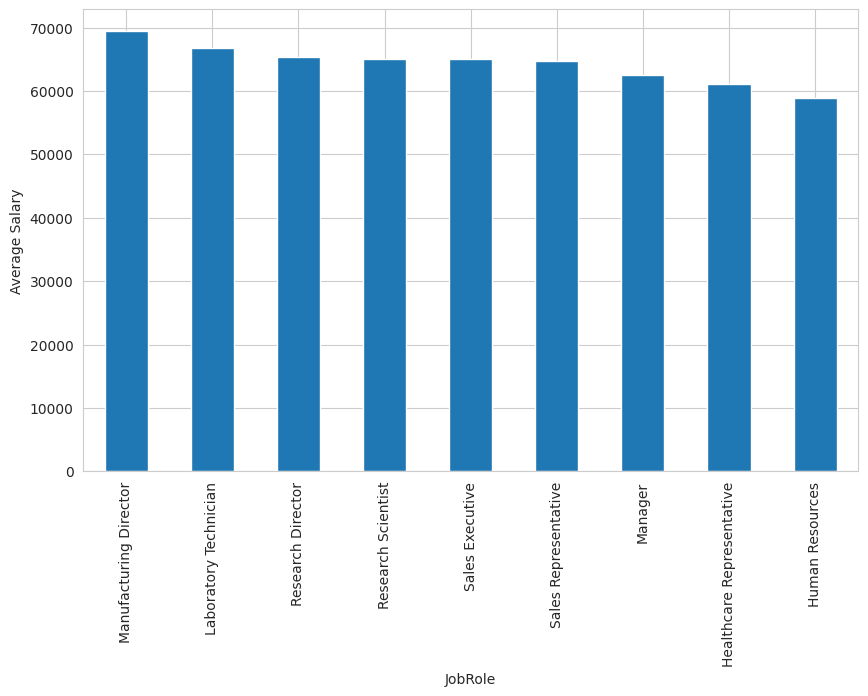

In [27]:
# Top 10 Highest Paid Job Roles
salary=df.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))

salary.head(10).plot(kind='bar')
plt.ylabel('Average Salary')
plt.show()


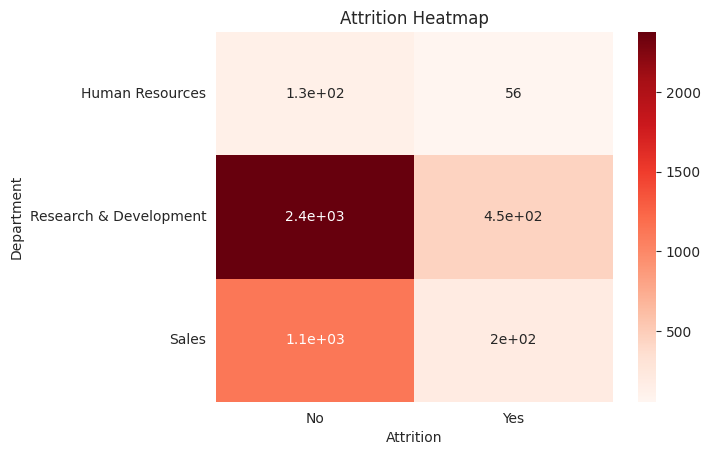

In [28]:
# Attrition Heatmap
pivot=pd.crosstab(
    df['Department'],
    df['Attrition']
)
sns.heatmap(
    pivot,
    annot=True,
    cmap='Reds'
)
plt.title('Attrition Heatmap')
plt.show()


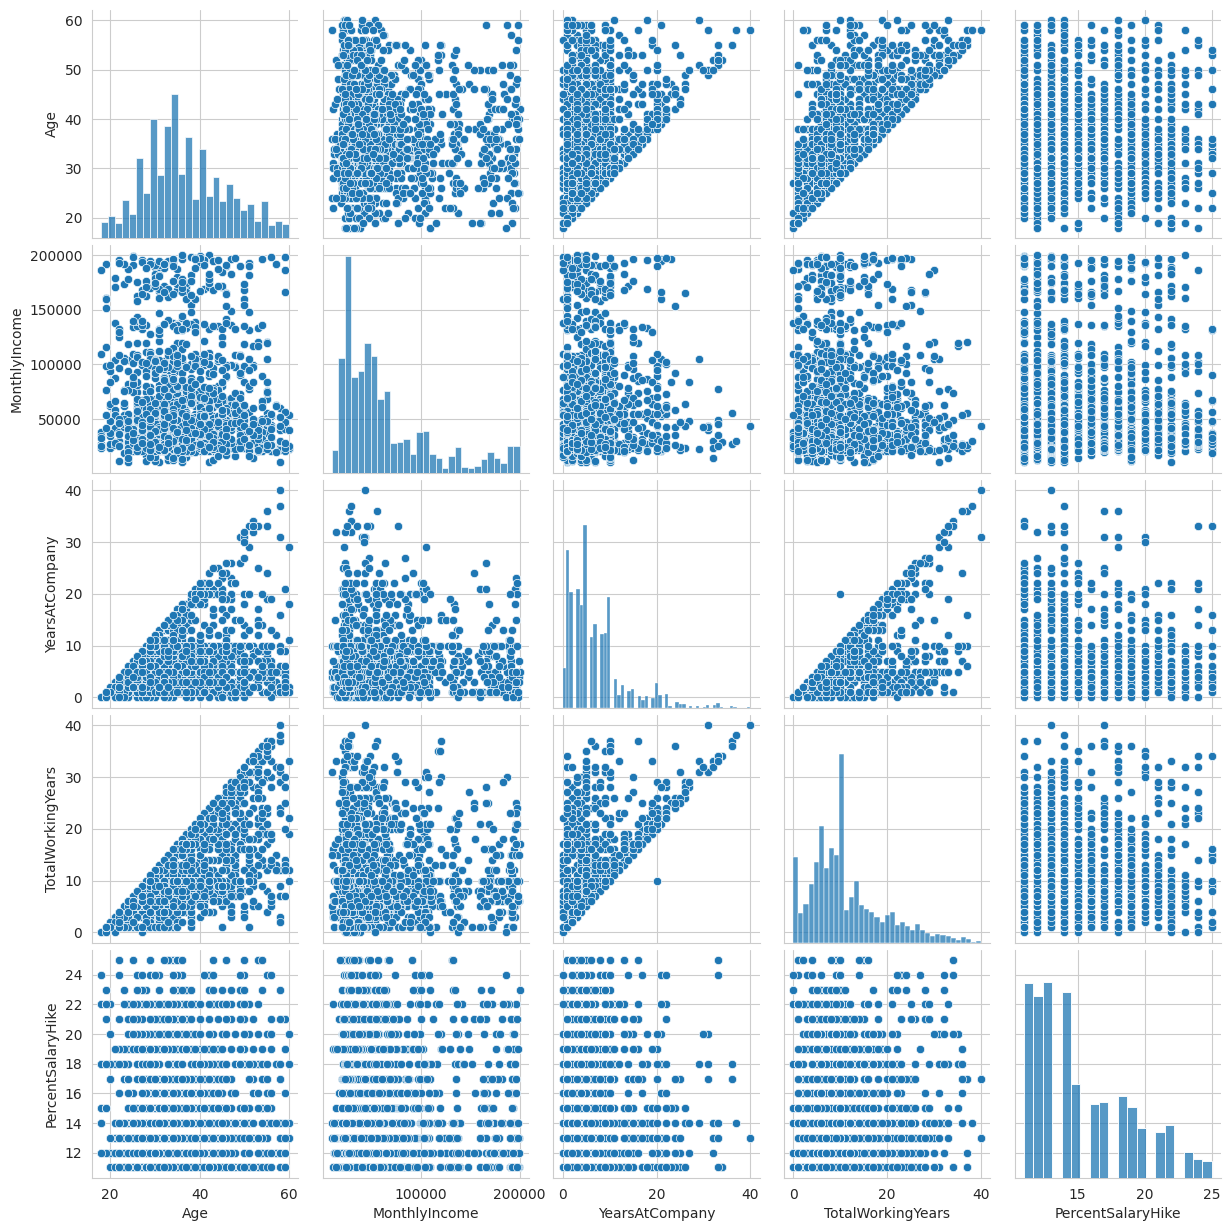

In [29]:
# Pair Plot
cols=[
'Age',
'MonthlyIncome',
'YearsAtCompany',
'TotalWorkingYears',
'PercentSalaryHike'
]

sns.pairplot(df[cols])
plt.show()


## 4. Statistical Significance Testing

Section 3 showed visual differences in attrition across department, work-life balance, and age.
This section checks whether those differences are statistically significant or could plausibly be
due to chance — especially important for smaller subgroups like Human Resources (n=188).

- **Chi-square test of independence** for categorical variables vs. Attrition (Yes/No)
- **Welch's t-test** for Age (continuous) between employees who left vs. stayed

In [30]:
# Chi-square tests: categorical variables vs Attrition
categorical_vars = ['Department', 'WorkLifeBalance', 'JobSatisfaction', 'MaritalStatus', 'BusinessTravel']

results = []
for col in categorical_vars:
    ct = pd.crosstab(df[col], df['Attrition'])
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    results.append({
        'Variable': col,
        'Chi2': round(chi2, 2),
        'p_value': round(p, 6),
        'Significant (p<0.05)': p < 0.05
    })

chi2_results = pd.DataFrame(results)
chi2_results


,Variable,Chi2,p_value,Significant (p<0.05)
0,Department,27.12,0.000001,True
1,WorkLifeBalance,46.73,0.000000,True
2,JobSatisfaction,51.21,0.000000,True
3,MaritalStatus,134.44,0.000000,True
4,BusinessTravel,68.20,0.000000,True


**Finding:** All five variables show a statistically significant association with attrition
(p < 0.05 in every case — most are p < 0.000001). This confirms the department, work-life balance,
and job satisfaction patterns seen in Section 3 are real signal, not noise from small subgroups —
including Human Resources, despite its small headcount.

In [31]:
# Welch's t-test: Age between employees who left vs stayed
age_yes = df[df['Attrition'] == 'Yes']['Age']
age_no = df[df['Attrition'] == 'No']['Age']

t_stat, p_value = ttest_ind(age_yes, age_no, equal_var=False)

print(f"Mean age (Attrition = Yes): {age_yes.mean():.1f}")
print(f"Mean age (Attrition = No):  {age_no.mean():.1f}")
print(f"t-statistic: {t_stat:.2f}")
print(f"p-value:     {p_value:.6f}")


Mean age (Attrition = Yes): 33.7
Mean age (Attrition = No):  37.5
t-statistic: -9.81
p-value:     0.000000


**Finding:** Employees who left are on average **~3.8 years younger** (33.7 vs 37.5), and this
difference is highly statistically significant (p < 0.000001). The "younger employees attrite more"
pattern from the dashboard is a real effect, not a visual illusion from the chart's scale.

## 5. Validating the HR Risk Score

The Power BI dashboard includes a rule-based `HRRiskScore` (High / Medium / Low) built from a CASE
expression in SQL — an employee is flagged **High Risk** if they have low job satisfaction, short
tenure, *and* poor work-life balance together.

This section replicates that rule in Python and checks whether it actually separates people who left
from people who stayed, rather than assuming the thresholds are meaningful just because they sound
reasonable.

In [32]:
def hr_risk_score(row):
    if row['JobSatisfaction'] <= 2 and row['YearsAtCompany'] < 3 and row['WorkLifeBalance'] <= 2:
        return 'High Risk'
    elif row['JobSatisfaction'] <= 2 or row['WorkLifeBalance'] <= 2:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['HRRiskScore'] = df.apply(hr_risk_score, axis=1)

# How many employees fall into each tier, and what's the actual attrition rate within each?
tier_summary = df.groupby('HRRiskScore').agg(
    Employees=('EmployeeID', 'count'),
    Attrition_Rate_Pct=('Attrition', lambda s: round((s == 'Yes').mean() * 100, 2))
).reindex(['High Risk', 'Medium Risk', 'Low Risk'])

tier_summary


,Employees,Attrition_Rate_Pct
HRRiskScore,,
High Risk,87,41.38
Medium Risk,2383,18.51
Low Risk,1857,12.06


**Finding:** The risk tiers show a real, meaningful gradient — **41.4% attrition in the "High Risk"
tier vs. 12.1% in "Low Risk"**, a >3x difference. So the rule isn't arbitrary; it does separate
higher-risk employees from lower-risk ones.

**Caveat worth stating honestly:** only 87 employees (2% of the workforce) fall into "High Risk," so
this tier's exact rate should be read as directional rather than precise — with a small sample,
individual outcomes can shift the percentage noticeably. This is a rule-based heuristic validated
against outcomes, not a trained/tested predictive model — worth being explicit about that distinction
if asked in an interview.

## 6. Summary Statistics

In [33]:
print("Total Employees :", len(df))

print("Attrition Rate :",
round((df['Attrition']=="Yes").mean()*100,2),"%")

print("Average Salary :",
round(df['MonthlyIncome'].mean(),2))

print("Average Age :",
round(df['Age'].mean()))

print("Average Experience :",
round(df['TotalWorkingYears'].mean(),2))


Total Employees : 4327
Attrition Rate : 16.2 %
Average Salary : 65029.24
Average Age : 37
Average Experience : 11.27


## 7. Export to Database

Loads the cleaned dataset into MySQL for the SQL analysis layer. Credentials are read from
environment variables rather than hardcoded, so this notebook is safe to share or commit to a
public repository — set `DB_USER`, `DB_PASSWORD`, `DB_HOST`, and `DB_NAME` in your local
environment (or a `.env` file that is **not** committed) before running this cell.

In [34]:
import os
from sqlalchemy import create_engine

db_user = os.getenv("DB_USER", "root")
db_password = os.getenv("DB_PASSWORD")
db_host = os.getenv("DB_HOST", "localhost")
db_name = os.getenv("DB_NAME", "hr_analysis")

if not db_password:
    raise ValueError(
        "DB_PASSWORD environment variable is not set. "
        "Set it before running this cell — do not hardcode credentials here."
    )

engine = create_engine(
    f"mysql+mysqlconnector://{db_user}:{db_password}@{db_host}/{db_name}"
)

df.to_sql(
    name="employee_data",
    con=engine,
    if_exists="replace",   # or "append"
    index=False
)


ValueError: DB_PASSWORD environment variable is not set. Set it before running this cell — do not hardcode credentials here.